# INFO-6147-(01)-26W Deep Learning with TensorFlow/Keras

## Project: Flavor Bridge

**Student Name:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 30th, 2026

**GitHub:** https://github.com/virwang/Tensorflow-Keras_Fanshawe.git

**Description:**

This project aims to allow users to upload photos of food and describe what the food tastes like. It will be helpful when traveling or when people want to try international food but don't have someone to explain it.
Here comes this AI project, to assist people on observing new foods.

## Setup Environment

In [ ]:
# !pip install datasets gradio streamlit groq pyngrok

# # Download Cloudflare tunnel tool (for Streamlit tunneling in Colab)
# !wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
# !dpkg -i cloudflared-linux-amd64.deb

--2026-04-12 04:24:24--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb [following]
--2026-04-12 04:24:24--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/ec689fe1-d727-4ebd-bbc3-5967730ab54e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-12T05%3A19%3A20Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64.deb&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&

## Import Libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import zipfile
import io

# ── TensorFlow / Keras ──────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications, optimizers, callbacks

# sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import seaborn as sns
from tqdm import tqdm

from google.colab import userdata, runtime, drive

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")

TensorFlow version: 2.19.0
Keras version:      3.13.2


## Check Device

TensorFlow automatically uses the GPU when available.

In [12]:
#if is GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Allow memory growth so TF doesn't grab all GPU RAM at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU detected: {gpus[0].name}")
    DEVICE = 'GPU'
else:
    print("No GPU found – running on CPU")
    DEVICE = 'CPU'

# Enable mixed precision (equivalent to torch.cuda.amp.autocast + GradScaler)
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f"Mixed precision policy: {tf.keras.mixed_precision.global_policy().name}")

No GPU found – running on CPU
Mixed precision policy: mixed_float16


## Define Path Parameters

In [13]:
SOURCE_DRIVE_ZIP  = "/content/drive/MyDrive/food-101.tar.gz"
TARGET_LOCAL_ROOT = "/content/food101_local"

# Best-model save path  (TF uses .keras or SavedModel format instead of .pth)
MODEL_SAVE_PATH = "/content/drive/MyDrive/food_best.keras"

## Connect to Google Drive

In [14]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preparation & Curation

### Define Food Types for Subset

In [15]:
select_food_list = sorted([
    # --- Asia ---
    'bibimbap', 'gyoza', 'sashimi', 'pad_thai', 'pho',
    'miso_soup', 'edamame', 'spring_rolls', 'sushi', 'dumplings',
    'hummus', 'falafel', 'baklava', 'chicken_curry', 'fried_rice',

    # --- Latino ---
    'tacos', 'guacamole', 'ceviche', 'nachos',

    # --- Classic ---
    'pizza', 'hamburger', 'hot_dog', 'steak', 'french_fries',
    'grilled_salmon', 'spaghetti_bolognese', 'lasagna', 'club_sandwich',

    # --- Hot in Social Media ---
    'tiramisu', 'cheesecake', 'macarons', 'donuts', 'waffles',
    'pancakes', 'ice_cream', 'apple_pie', 'strawberry_shortcake',

    # --- Seafood ---
    'mussels', 'oysters',

    # --- Europe ---
    'escargots'
])

# Mapping dictionaries
class_to_idx = {cls_name: i for i, cls_name in enumerate(select_food_list)}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}
label_to_name = {i: name for i, name in enumerate(select_food_list)}
print(label_to_name)

select = [
    {"Class Index": class_idx, "Class Name": class_name}
    for class_name, class_idx in class_to_idx.items()
]
df_select = pd.DataFrame(select)
display(df_select.head())

{0: 'apple_pie', 1: 'baklava', 2: 'bibimbap', 3: 'ceviche', 4: 'cheesecake', 5: 'chicken_curry', 6: 'club_sandwich', 7: 'donuts', 8: 'dumplings', 9: 'edamame', 10: 'escargots', 11: 'falafel', 12: 'french_fries', 13: 'fried_rice', 14: 'grilled_salmon', 15: 'guacamole', 16: 'gyoza', 17: 'hamburger', 18: 'hot_dog', 19: 'hummus', 20: 'ice_cream', 21: 'lasagna', 22: 'macarons', 23: 'miso_soup', 24: 'mussels', 25: 'nachos', 26: 'oysters', 27: 'pad_thai', 28: 'pancakes', 29: 'pho', 30: 'pizza', 31: 'sashimi', 32: 'spaghetti_bolognese', 33: 'spring_rolls', 34: 'steak', 35: 'strawberry_shortcake', 36: 'sushi', 37: 'tacos', 38: 'tiramisu', 39: 'waffles'}


,Class Index,Class Name
0,0,apple_pie
1,1,baklava
2,2,bibimbap
3,3,ceviche
4,4,cheesecake


#### Clean Up Old Data & Extract from Google Drive

In [16]:
# 1. Clean up old data to avoid 'Ghost Folders'
!rm -rf /content/food101_local
os.makedirs(TARGET_LOCAL_ROOT, exist_ok=True)

In [17]:
# 2. Extract only the 40 selected categories from the archive
extract_targets = [f"food-101/images/{food}" for food in select_food_list]
extract_targets.append("food-101/meta")
targets_str = " ".join(extract_targets)

print(f"🚀 Extracting ONLY {len(select_food_list)} categories...")
!tar -xzf "{SOURCE_DRIVE_ZIP}" -C "{TARGET_LOCAL_ROOT}" {targets_str}

# 3. Validate
images_path = os.path.join(TARGET_LOCAL_ROOT, "food-101/images")
actual_folders = os.listdir(images_path)
print(f"✅ Extraction successful! Total folders: {len(actual_folders)}")

if len(actual_folders) != 40:
    print(f"⚠️ Warning: Expected 40 but found {len(actual_folders)}")

🚀 Extracting ONLY 40 categories...
✅ Extraction successful! Total folders: 40


## Data Pipeline Infrastructure

### Hyperparameters

In [ ]:
EPOCHS       = 50
BATCH_SIZE   = 128
LEARNING_RATE = 0.0001
PATIENCE     = 10   # early stopping
IMG_SIZE     = 224  # ResNet50 input size
NUM_CLASSES  = len(select_food_list)  # 40

### Load Dataset, Split & Build tf.data Pipelines

**TensorFlow approach:** Collect file paths + labels → stratified split → `tf.data.Dataset` with `map()` for transforms

In [ ]:
# ── 1. Collect all image paths and their integer labels ───────────────────────
all_paths, all_labels = [], []

# ImageFolder orders classes alphabetically – we match that here
extracted_classes = sorted(os.listdir(images_path))
extracted_class_to_idx = {cls: i for i, cls in enumerate(extracted_classes)}

for class_name in extracted_classes:
    class_dir = os.path.join(images_path, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(class_dir, fname))
            all_labels.append(extracted_class_to_idx[class_name])

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
print(f"✅ Total images collected: {len(all_paths)}")
print(f"✅ Total classes detected: {len(extracted_classes)}")
print(f"✅ Sample mapping (first 3): {dict(list(extracted_class_to_idx.items())[:3])}")

# ── 2. Stratified split: 80% Train | 10% Val | 10% Test ──────────────────────
indices = np.arange(len(all_paths))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, stratify=all_labels, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=all_labels[temp_idx], random_state=42
)

print(f"\n📊 Final Data Preprocessing Complete:")
print(f"Total Classes: {len(extracted_classes)}")
print(f"Training size: {len(train_idx)} (Augmented)")
print(f"Validation size: {len(val_idx)} (Clean)")
print(f"Test size: {len(test_idx)} (Clean)")

✅ Total images collected: 40000
✅ Total classes detected: 40
✅ Sample mapping (first 3): {'apple_pie': 0, 'baklava': 1, 'bibimbap': 2}

📊 Final Data Preprocessing Complete:
Total Classes: 40
Training size: 32000 (Augmented)
Validation size: 4000 (Clean)
Test size: 4000 (Clean)


In [ ]:
# ── 3. Image loading helper ───────────────────────────────────────────────────
def load_image(path, label):
    """Read a JPEG/PNG from disk and decode it."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    return img, label


# ── 4. Augmentation transforms ────────────────────────────────────────────────
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

def normalize(img):
    """ImageNet normalization (same values as PyTorch version)."""
    img = img / 255.0
    return (img - IMAGENET_MEAN) / IMAGENET_STD

def train_augment(img, label):
    """Training augmentation pipeline."""
    # RandomResizedCrop(224)
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE + 32, IMG_SIZE + 32)
    img = tf.image.random_crop(img, size=[IMG_SIZE, IMG_SIZE, 3])
    # RandomHorizontalFlip
    img = tf.image.random_flip_left_right(img)
    # RandomRotation(15 degrees) — applied via keras preprocessing layer
    img = tf.py_function(
        lambda x: tf.keras.preprocessing.image.apply_affine_transform(
            x.numpy(), theta=np.random.uniform(-15, 15)
        ),
        [img], tf.float32
    )
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    img = normalize(img)
    return img, label

def eval_transform(img, label):
    """Validation / test transform: Resize(256) → CenterCrop(224) → Normalize."""
    img = tf.image.resize(img, [256, 256])
    # CenterCrop to 224
    offset = (256 - IMG_SIZE) // 2
    img = img[offset:offset + IMG_SIZE, offset:offset + IMG_SIZE, :]
    img = normalize(img)
    return img, label


# ── 5. Build tf.data.Dataset objects ─────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

def build_dataset(paths, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(train_augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(buffer_size=5000, reshuffle_each_iteration=True)
    else:
        ds = ds.map(eval_transform, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(all_paths[train_idx], all_labels[train_idx], augment=True)
val_ds   = build_dataset(all_paths[val_idx],   all_labels[val_idx],   augment=False)
test_ds  = build_dataset(all_paths[test_idx],  all_labels[test_idx],  augment=False)

print("✅ tf.data pipelines ready.")

✅ tf.data pipelines ready.


#### Validate Selected Food Labels

In [ ]:
sorted_original_list = sorted(select_food_list)
is_match = (extracted_classes == sorted_original_list)

print("--- Synchronization Check ---")
print(f"Detected Classes:  {len(extracted_classes)}")
print(f"Your Original List: {len(sorted_original_list)}")
print(f"Perfect Match? {is_match}")

if not is_match:
    missing = set(sorted_original_list) - set(extracted_classes)
    extra   = set(extracted_classes) - set(sorted_original_list)
    if missing: print(f"❌ Missing on disk: {missing}")
    if extra:   print(f"⚠️  Extra on disk: {extra}")
else:
    print("✅ Success: The labels 0-39 match your list perfectly.")

--- Synchronization Check ---
Detected Classes:  40
Your Original List: 40
Perfect Match? True
✅ Success: The labels 0-39 match your list perfectly.


## Build the Model

**TensorFlow/Keras:** `tf.keras.applications.ResNet50(weights='imagenet')` + custom Dense head

In [ ]:
def build_food_model(num_classes: int) -> keras.Model:
    """
    ResNet-50 backbone with a custom classification head.
    """
    # ── Backbone (pre-trained on ImageNet, feature-extraction first) ──────────
    base_model = applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    # Unfreeze all layers (fine-tuning, same as PyTorch default)
    base_model.trainable = True

    # ── Custom classification head ────────────────────────────────────────────
    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base_model(inputs, training=True)
    x       = layers.GlobalAveragePooling2D()(x)   # replaces AdaptiveAvgPool2d

    # Layer 1 – Linear(2048→1024) + BN + ReLU + Dropout
    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    # Layer 2 – Linear(1024→512) + BN + ReLU
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Output – Linear(512→num_classes)
    # dtype=float32 keeps the output in full precision even with mixed_float16
    outputs = layers.Dense(num_classes, dtype='float32')(x)

    return keras.Model(inputs, outputs, name='FlavourBridge_ResNet50')


model = build_food_model(NUM_CLASSES)
model.summary(line_length=80)

Model: "FlavourBridge_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ resnet50 (Functional)             │ (None, 7, 7, 2048)       │    23,587,712 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 2048)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 1024)             │     2,098,176 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 1024)             │         4,096 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation (Activation)           │ (None, 1024)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 1024)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 512)              │       524,800 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_1             │ (None, 512)              │         2,048 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_1 (Activation)         │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 40)               │        20,520 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 26,237,352 (100.09 MB)

 Trainable params: 26,181,160 (99.87 MB)

 Non-trainable params: 56,192 (219.50 KB)

In [ ]:
# ── Compile ───────────────────────────────────────────────────────────────────
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("✅ Model compiled.")

✅ Model compiled.


## Define the FoodClassifier Training Wrapper

In [ ]:
# 1. Save the best model (by val_loss)
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

# 2. Reduce LR on plateau
reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    mode='min',
    verbose=1
)

# 3. Early stopping
early_stop_cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    mode='min',
    restore_best_weights=True,   # auto-loads best weights at end of training
    verbose=1
)

print("✅ Callbacks configured.")

✅ Callbacks configured.


## Start Training

In [ ]:
print(f"Training started (ResNet-50 / {NUM_CLASSES} Classes)")
print(f"Save destination: {MODEL_SAVE_PATH}\n")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# start training
history_obj = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb],
    verbose=1
)

# history record
history = {
    'train_loss': history_obj.history['loss'],
    'train_acc':  [v * 100 for v in history_obj.history['accuracy']],
    'test_loss':  history_obj.history['val_loss'],
    'test_acc':   [v * 100 for v in history_obj.history['val_accuracy']],
    'lr':         history_obj.history.get('lr', [])
}

print("\n✅ Training complete.")

Training started (ResNet-50 / 40 Classes)
Save destination: /content/drive/MyDrive/food_best.keras

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.2784 - loss: 2.8534
Epoch 1: val_loss improved from None to 4.10106, saving model to /content/drive/MyDrive/food_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/food_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 1083s 436ms/step - accuracy: 0.4164 - loss: 2.2519 - val_accuracy: 0.0510 - val_loss: 4.1011 - learning_rate: 1.0000e-04
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.6983 - loss: 1.1500
Epoch 2: val_loss improved from 4.10106 to 2.69418, saving model to /content/drive/MyDrive/food_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/food_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 97s 389ms/step - accuracy: 0.6967 - loss: 1.1392 - val_accuracy: 0.3043 - val_loss: 2.6942 - learning_rate: 1.0000e-04
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0

### Collect Final Predictions on the Test Set

In [ ]:
def get_final_predictions(model, dataset):
    """
    Run inference on the entire dataset and return (y_true, y_pred).
    Equivalent to FoodClassifier._get_final_predictions().
    """
    y_true, y_pred = [], []
    for images, labels in tqdm(dataset, desc="Evaluating"):
        logits = model(images, training=False)          # forward pass
        preds  = tf.argmax(logits, axis=1).numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)


# Load best weights (EarlyStopping already restores them, but we can reload explicitly)
best_model = keras.models.load_model(MODEL_SAVE_PATH)

final_y_true, final_y_pred = get_final_predictions(best_model, test_ds)

# Compute F1 for history dict (same as validate() in the PyTorch version)
history['test_f1'] = []   # epoch-level F1 is not tracked by Keras natively
final_f1 = f1_score(final_y_true, final_y_pred, average='macro')
print(f"\nFinal Test Macro F1-Score: {final_f1:.4f}")

Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.49it/s]


Final Test Macro F1-Score: 0.6116


## Model Evaluation


In [ ]:
class ModelEvaluator:
    """
    Evaluate model performance: metrics, confusion matrix,
    detailed report, and visual inference.
    """

    def __init__(self, history, y_true, y_pred, class_names, model=None, test_ds=None):
        self.history     = history
        self.y_true      = np.array(y_true)
        self.y_pred      = np.array(y_pred)
        self.class_names = class_names
        self.model       = model
        self.test_ds     = test_ds

    # ── Plot helpers ───────────────────────────────────────────────────────────

    def plot_accuracy(self):
        """Show Accuracy curve."""
        plt.figure(figsize=(10, 6))
        epochs = range(1, len(self.history['train_loss']) + 1)
        plt.plot(epochs, self.history['train_acc'], 'g-o', label='Train Acc', markersize=4)
        plt.plot(epochs, self.history['test_acc'],  'm-s', label='Val Acc',   markersize=4)
        plt.title('Accuracy Trend: Training vs Validation', fontsize=15, pad=15)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Accuracy (%)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

    def plot_loss(self):
        """Show Loss convergence."""
        plt.figure(figsize=(10, 6))
        epochs = range(1, len(self.history['train_loss']) + 1)
        plt.plot(epochs, self.history['train_loss'], 'b-o', label='Train Loss', markersize=4)
        plt.plot(epochs, self.history['test_loss'],  'r-s', label='Val Loss',   markersize=4)
        plt.title('Loss Convergence: Training vs Validation', fontsize=15, pad=15)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Loss Value', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

    def plot_learning_rate(self):
        """Show Learning Rate schedule."""
        if self.history.get('lr') and len(self.history['lr']) > 0:
            plt.figure(figsize=(10, 6))
            epochs = range(1, len(self.history['lr']) + 1)
            plt.plot(epochs, self.history['lr'], 'k-x', label='LR')
            plt.yscale('log')
            plt.title('Learning Rate Schedule', fontsize=15, pad=15)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('LR (Log Scale)', fontsize=12)
            plt.grid(True, which='both', ls='-', alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No Learning Rate data recorded in history.")

    def plot_f1_score(self):
        """Show F1-Score trend (if available)."""
        if self.history.get('test_f1') and len(self.history['test_f1']) > 0:
            plt.figure(figsize=(10, 6))
            epochs = range(1, len(self.history['test_f1']) + 1)
            plt.plot(epochs, self.history['test_f1'], 'c-^', label='Test F1 (Macro)')
            plt.title('Model Balance: F1-Score Trend', fontsize=15, pad=15)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('F1 Score', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No per-epoch F1 data. See print_detailed_analysis() for the final F1.")

    def plot_confusion_matrix(self, figsize=(18, 14)):
        """Filtered Confusion Matrix: Top 5 & Worst 5 categories by F1."""
        report = classification_report(
            self.y_true, self.y_pred,
            target_names=self.class_names,
            output_dict=True, zero_division=0
        )
        class_stats  = {k: v['f1-score'] for k, v in report.items() if k in self.class_names}
        sorted_cls   = sorted(class_stats.items(), key=lambda x: x[1], reverse=True)
        top_5        = [x[0] for x in sorted_cls[:5]]
        worst_5      = [x[0] for x in sorted_cls[-5:]]
        selected_cls = top_5 + worst_5
        indices      = [list(self.class_names).index(c) for c in selected_cls]

        cm          = confusion_matrix(self.y_true, self.y_pred)
        filtered_cm = cm[np.ix_(indices, indices)]

        plt.figure(figsize=figsize)
        sns.heatmap(filtered_cm, annot=True, fmt='d', cmap='YlGnBu',
                    xticklabels=selected_cls, yticklabels=selected_cls,
                    annot_kws={'size': 10})
        plt.title('Confusion Matrix: Top 5 & Worst 5 Categories', fontsize=16)
        plt.ylabel('Actual Food Type', fontsize=12)
        plt.xlabel('Predicted Food Type', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.5)
        plt.axvline(x=5, color='red', linestyle='--', linewidth=2, alpha=0.5)
        plt.text(0.5, 4.8,  'Top 5',   color='green', fontweight='bold')
        plt.text(5.5, 9.8,  'Worst 5', color='red',   fontweight='bold')
        plt.tight_layout()
        plt.show()

    def print_detailed_analysis(self):
        """Classification report + worst 5 classes."""
        print("\n" + "=" * 60)
        print("DETAILED CLASSIFICATION PERFORMANCE")
        print("=" * 60)
        all_labels = list(range(len(self.class_names)))
        report = classification_report(
            self.y_true, self.y_pred,
            target_names=self.class_names,
            labels=all_labels,
            output_dict=True, zero_division=0
        )
        class_stats = {k: v for k, v in report.items() if k in self.class_names}
        worst_5     = sorted(class_stats.items(), key=lambda x: x[1]['f1-score'])[:5]

        print(f"{'Food Class':<20} | {'F1-Score':<10} | {'Precision':<10} | {'Recall':<10}")
        print("-" * 60)
        for name, stats in worst_5:
            print(f"{name:<20} | {stats['f1-score']:.4f} | {stats['precision']:.4f} | {stats['recall']:.4f}")

        final_f1 = f1_score(self.y_true, self.y_pred, average='macro')
        print(f"\nFinal Macro F1-Score: {final_f1:.4f}")

    def visualize_predictions(self, num_images=15):
        """
        Visual Inference (True vs Pred) on the test set.

        PyTorch used: model.eval() + torch.no_grad() + denormalize CHW→HWC
        Keras uses:   model(x, training=False) + denormalize HWC directly
        """
        if self.model is None or self.test_ds is None:
            print("Error: model and test_ds must be provided for visualization.")
            return

        MEAN = np.array([0.485, 0.456, 0.406])
        STD  = np.array([0.229, 0.224, 0.225])

        all_images, all_labels, all_preds = [], [], []

        for images, labels in self.test_ds:
            logits = self.model(images, training=False)
            preds  = tf.argmax(logits, axis=1).numpy()
            all_images.extend(images.numpy())
            all_labels.extend(labels.numpy())
            all_preds.extend(preds)
            if len(all_images) >= num_images:
                break

        plt.figure(figsize=(20, 12))
        plt.suptitle("Final Inference: Sample Predictions", fontsize=20)

        for i in range(num_images):
            ax = plt.subplot(3, 5, i + 1)
            ax.axis('off')

            # De-normalize: img is already HWC float32
            img = np.clip(STD * all_images[i] + MEAN, 0, 1)

            true_name = self.class_names[all_labels[i]]
            pred_name = self.class_names[all_preds[i]]
            color     = 'green' if all_labels[i] == all_preds[i] else 'red'

            plt.imshow(img)
            ax.set_title(
                f"True: {true_name}\nPred: {pred_name}",
                color=color, fontsize=10, fontweight='bold'
            )

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

## Run Evaluation

In [ ]:
evaluation = ModelEvaluator(
    history=history,
    y_true=final_y_true,
    y_pred=final_y_pred,
    class_names=extracted_classes,
    model=best_model,
    test_ds=test_ds
)

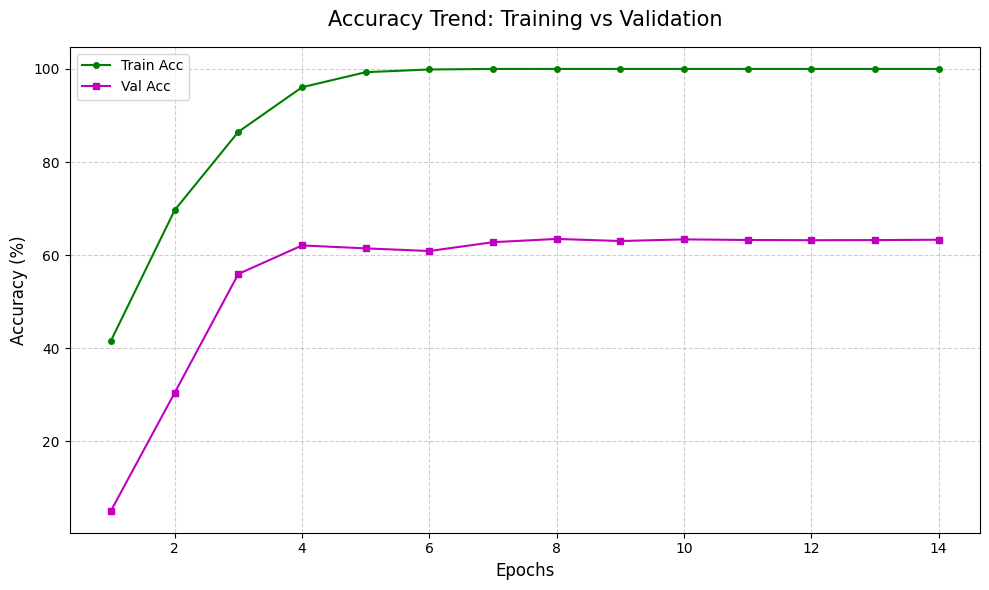

In [ ]:
evaluation.plot_accuracy()

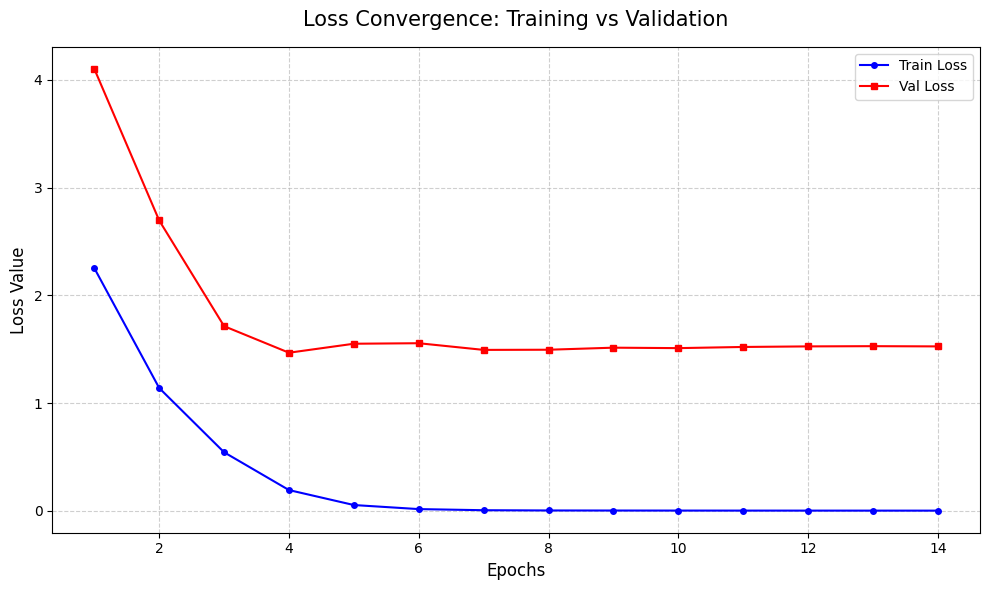

In [ ]:
evaluation.plot_loss()

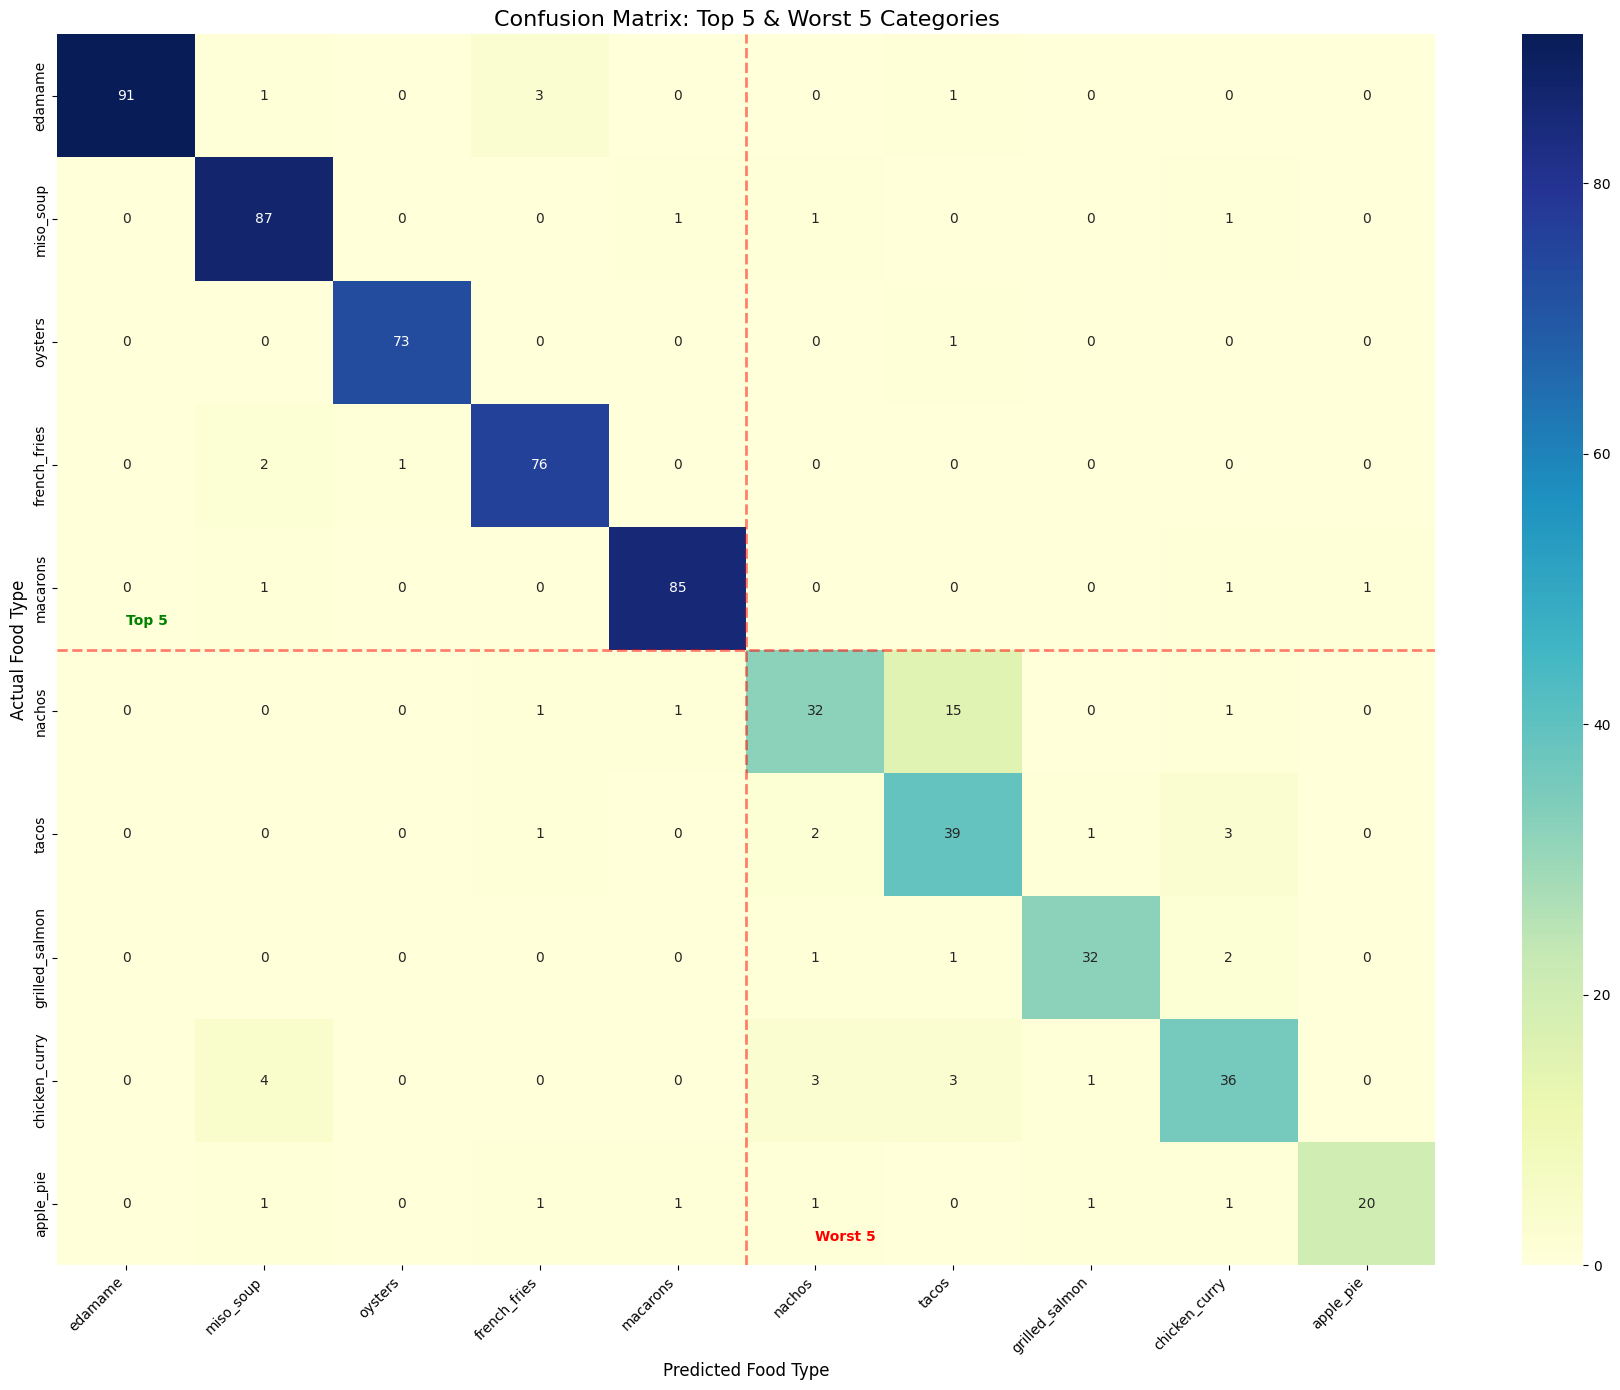

In [ ]:
evaluation.plot_confusion_matrix()

In [ ]:
evaluation.print_detailed_analysis()


DETAILED CLASSIFICATION PERFORMANCE
Food Class           | F1-Score   | Precision  | Recall    
------------------------------------------------------------
apple_pie            | 0.2797 | 0.4651 | 0.2000
chicken_curry        | 0.3789 | 0.4000 | 0.3600
grilled_salmon       | 0.3951 | 0.5161 | 0.3200
tacos                | 0.3980 | 0.4062 | 0.3900
nachos               | 0.4295 | 0.6531 | 0.3200

Final Macro F1-Score: 0.6116


In [ ]:
evaluation.visualize_predictions()

NameError: name 'evaluation' is not defined

## Observation Description

## Conclusion

## Questions to Ask AI

* Explain your hyperparameters
* What is data augmentation?
* Hyperparameter tuning
* Fine tuning vs. Feature extraction
* What is patience and how does it work?
* What is the ResNet model?
* Explain your code — what is it doing?
* What is `mixed_float16` and how does it replace `GradScaler`/`autocast`?
* What is `tf.data.Dataset` and how does it compare to `DataLoader`?